## Importações básicas

In [2]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.2.2-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (7.4 kB)
  Us

In [3]:
# Bibliotecas principais
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1782820078.196448    3401 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782820078.196821    3401 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782820078.417137    3401 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782820079.692812    3401 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Carregar o MSINT (dataset)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Forma dos dados de treino: (60000, 28, 28)
Forma dos dados de teste: (10000, 28, 28)
Forma dos labels de treino: (60000,)
Forma dos labels de teste: (10000,)


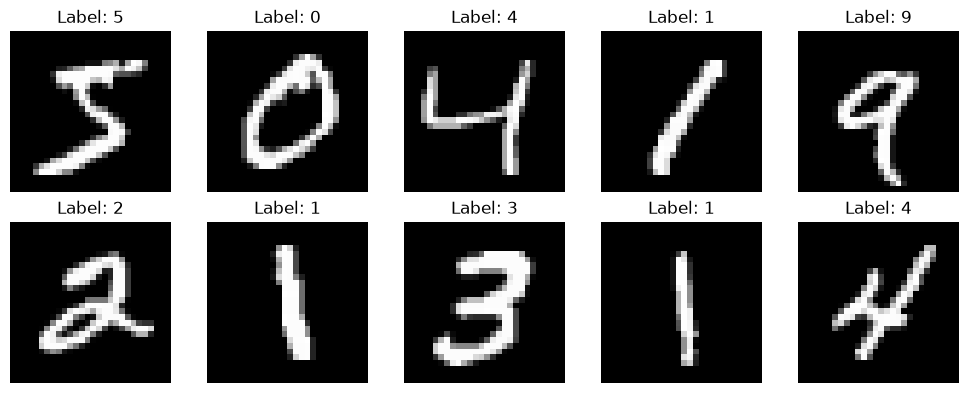


Valor mínimo dos pixels: 0
Valor máximo dos pixels: 255


In [4]:
# Carregar o dataset MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Verificar as dimensões
print(f"Forma dos dados de treino: {X_train.shape}")
print(f"Forma dos dados de teste: {X_test.shape}")
print(f"Forma dos labels de treino: {y_train.shape}")
print(f"Forma dos labels de teste: {y_test.shape}")

# Visualizar algumas imagens
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Verificar os valores dos pixels
print(f"\nValor mínimo dos pixels: {X_train.min()}")
print(f"Valor máximo dos pixels: {X_train.max()}")

## Pré-processamento dos dados

In [5]:
# 1. Normalização: Converter valores de [0, 255] para [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 2. Reshape: Achatar as imagens de 28x28 para vetor de 784
X_train_flatten = X_train.reshape(-1, 28 * 28)  # (60000, 784)
X_test_flatten = X_test.reshape(-1, 28 * 28)    # (10000, 784)

print(f"Forma após flatten (treino): {X_train_flatten.shape}")
print(f"Forma após flatten (teste): {X_test_flatten.shape}")

# 3. Verificar normalização
print(f"\nApós normalização:")
print(f"Valor mínimo: {X_train_flatten.min()}")
print(f"Valor máximo: {X_train_flatten.max()}")

# Os labels já estão no formato correto (0-9)
# Para usar com categorical_crossentropy, podemos converter para one-hot:
# y_train_onehot = keras.utils.to_categorical(y_train, 10)
# y_test_onehot = keras.utils.to_categorical(y_test, 10)

# Mas vamos usar sparse_categorical_crossentropy, que aceita labels inteiros
print(f"\nExemplo de labels: {y_train[:10]}")

Forma após flatten (treino): (60000, 784)
Forma após flatten (teste): (10000, 784)

Após normalização:
Valor mínimo: 0.0
Valor máximo: 1.0

Exemplo de labels: [5 0 4 1 9 2 1 3 1 4]
